In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1 - Load Dataset

df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT -- temperature
# V -- vaccum
# Ap -- pressure
# RH -- humidity

# PE -- produced energy -- output

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_train.head()

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [9]:
# 2 - convert into tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)   # numpy array
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1) # pandas dataframe

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # input_features, output_features
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# DEEP LEARNING

In [12]:
# Building ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden
            nn.Linear(X_train_tensor.shape[1], 6), # input_features, output_features
            nn.ReLU(),
    
            # 2nd Hidden
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [13]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [14]:
# Train the ANN for regression
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # Total training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb - features of 1 batch
        # yb - labels of 1 batch

        optimizer.zero_grad()
        outputs = model(xb) #forward propagation.......predicted outputs
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # Back propagation......compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb) #forward propagation.......predicted outputs
            loss = crietrion(outputs, yb) # compute loss
            running_val_loss += loss.item() # loss is tensor => py float

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

epoch 1/100 ==> train loss = 206248.218359375 & val loss = 204981.22265625
epoch 2/100 ==> train loss = 201209.51321614583 & val loss = 194320.178125
epoch 3/100 ==> train loss = 181338.1970703125 & val loss = 164920.45234375
epoch 4/100 ==> train loss = 144019.51751302084 & val loss = 122005.540625
epoch 5/100 ==> train loss = 100289.018359375 & val loss = 80074.57643229167
epoch 6/100 ==> train loss = 63720.797200520836 & val loss = 50164.354231770834
epoch 7/100 ==> train loss = 40183.26468098958 & val loss = 32289.42744140625
epoch 8/100 ==> train loss = 26441.13379720052 & val loss = 21795.397916666665
epoch 9/100 ==> train loss = 18552.417565917967 & val loss = 15769.477376302084
epoch 10/100 ==> train loss = 13838.15030110677 & val loss = 11979.344278971354
epoch 11/100 ==> train loss = 10635.33974609375 & val loss = 9114.609130859375
epoch 12/100 ==> train loss = 7959.760063680013 & val loss = 6576.173518880209
epoch 13/100 ==> train loss = 5579.331604003906 & val loss = 4416.3

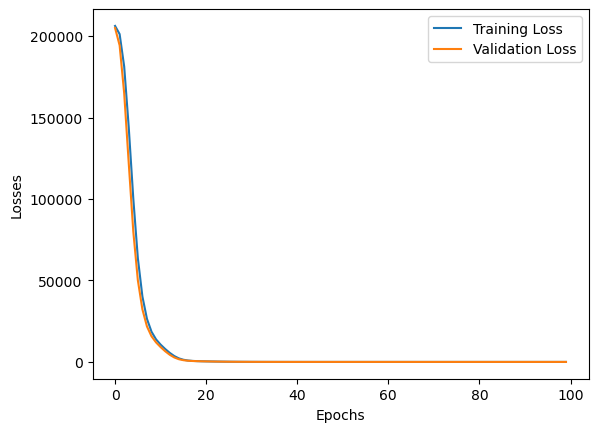

In [15]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(
    loss_df["Training Loss"],
    label = "Training Loss"
)

plt.plot(
    loss_df["Validation Loss"],
    label = "Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [16]:
# loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [17]:
# evaluate our model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  19.014387130737305
Testing MSE:  17.94680404663086


In [18]:
from sklearn.metrics import r2_score

print("r2 score: ", r2_score(y_test, test_preds))

r2 score:  0.9372805566112951


In [19]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted values,Actual values
0,436.698181,433.27
1,437.320892,438.16
2,461.752045,458.42
3,476.582672,480.82
4,437.978912,441.41
...,...,...
1909,450.739960,456.70
1910,433.160919,438.04
1911,465.293304,467.80
1912,432.509369,437.14
